In [58]:
# Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

In [59]:
# Load original data
df = pd.read_csv('../../data/processed/regression/export_insurance_portfolio_data_forecasting_2015_2025_feature_engineering.csv')


In [60]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2740 entries, 0 to 2739
Data columns (total 89 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   Jaar_Maand                                              2740 non-null   int64  
 1   Product                                                 2740 non-null   str    
 2   Label_Naam                                              2740 non-null   str    
 3   Beginstand                                              2740 non-null   int64  
 4   Jaarpremie_Beginstand                                   2740 non-null   float64
 5   Eindstand                                               2740 non-null   int64  
 6   Jaarpremie_Eindstand                                    2740 non-null   float64
 7   NewBusiness                                             2740 non-null   int64  
 8   Jaarpremie_NewBusiness                           

In [61]:
print(df.isnull().sum())

Jaar_Maand                          0
Product                             0
Label_Naam                          0
Beginstand                          0
Jaarpremie_Beginstand               0
                                   ..
Portfolio_Value_Growth_Ratio       10
Months_Since_Year_Start             0
Retention_Rate                      0
Market_Capture_Index                0
Label_Historical_Avg_Royementen     0
Length: 89, dtype: int64


In [62]:
df = df.dropna()

In [63]:
df.info()

<class 'pandas.DataFrame'>
Index: 2087 entries, 12 to 2739
Data columns (total 89 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   Jaar_Maand                                              2087 non-null   int64  
 1   Product                                                 2087 non-null   str    
 2   Label_Naam                                              2087 non-null   str    
 3   Beginstand                                              2087 non-null   int64  
 4   Jaarpremie_Beginstand                                   2087 non-null   float64
 5   Eindstand                                               2087 non-null   int64  
 6   Jaarpremie_Eindstand                                    2087 non-null   float64
 7   NewBusiness                                             2087 non-null   int64  
 8   Jaarpremie_NewBusiness                               

      Target       Mean  Median    Std Dev  Min  Max  Skewness  Kurtosis
  Royementen 104.869190    51.0 156.545457    1 1086  2.990093  9.334218
 NewBusiness 121.858649    58.0 194.167596    1 3180  4.525559 38.876497
Prolongaties 589.188788   274.0 914.659838    1 6543  3.240222 10.978993


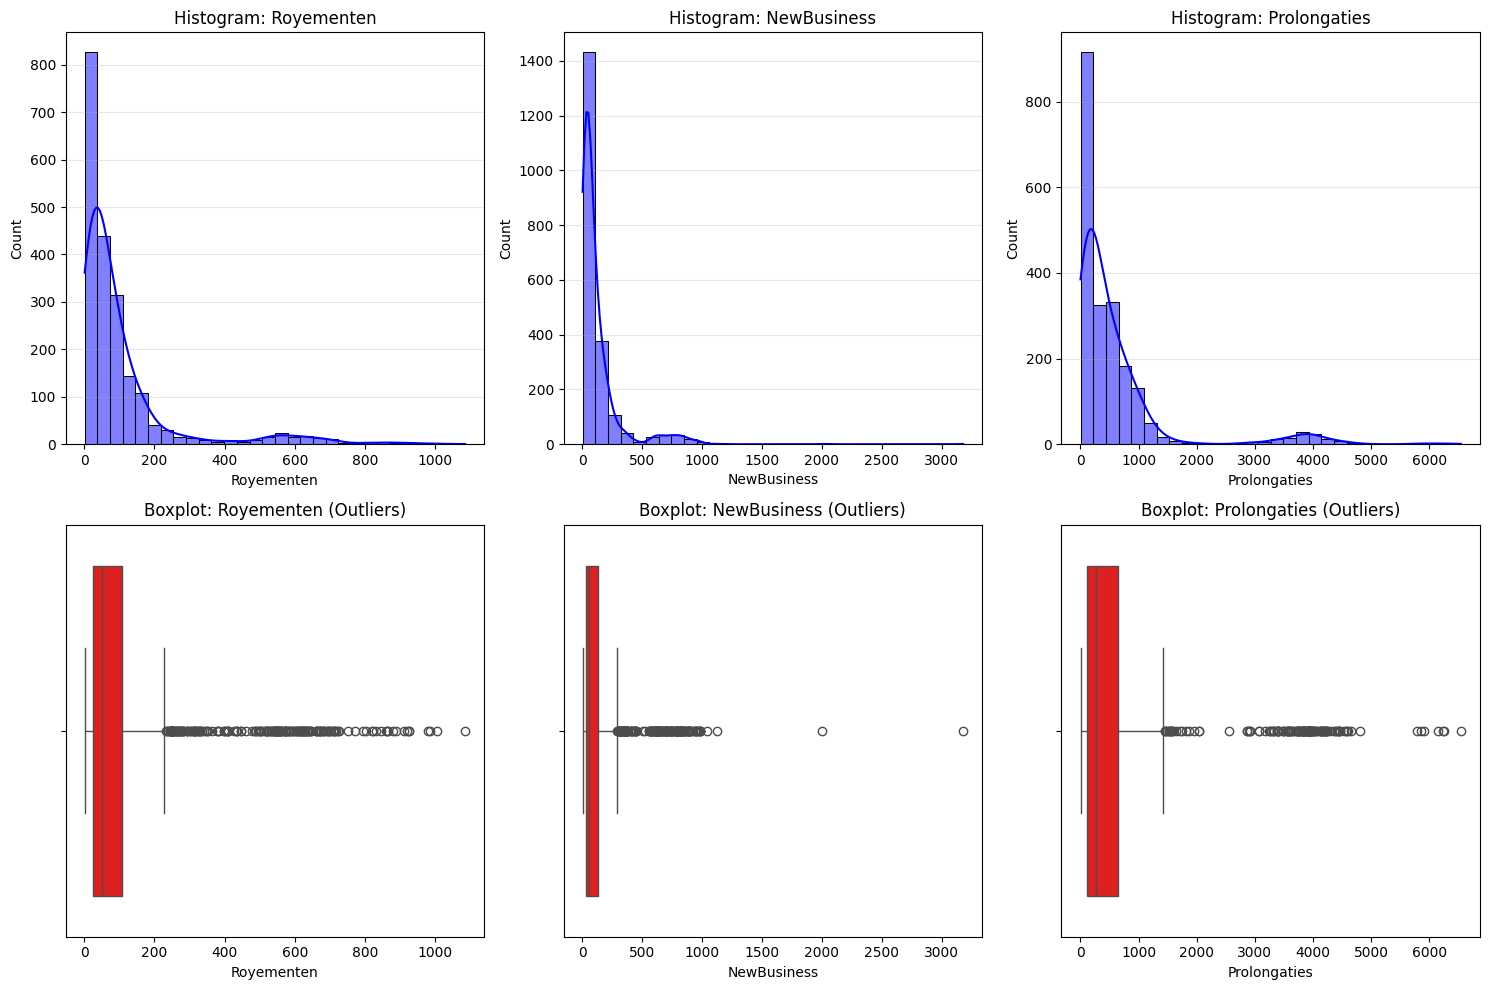

In [64]:
# Distribution analysis of original targets
df_orig = df.copy()

# Define targets
targets = ['Royementen', 'NewBusiness', 'Prolongaties']

# Calculate statistics
stats_list = []
for target in targets:
    stats_list.append({
        'Target': target,
        'Mean': df_orig[target].mean(),
        'Median': df_orig[target].median(),
        'Std Dev': df_orig[target].std(),
        'Min': df_orig[target].min(),
        'Max': df_orig[target].max(),
        'Skewness': skew(df_orig[target]),
        'Kurtosis': kurtosis(df_orig[target])
    })

stats_df = pd.DataFrame(stats_list)

# Generate plots
plt.figure(figsize=(15, 10))

# Histograms
for i, target in enumerate(targets):
    plt.subplot(2, 3, i+1)
    sns.histplot(df_orig[target], kde=True, bins=30, color='blue')
    plt.title(f'Histogram: {target}')
    plt.grid(axis='y', alpha=0.3)

# Boxplots
for i, target in enumerate(targets):
    plt.subplot(2, 3, i+4)
    sns.boxplot(x=df_orig[target], color='red')
    plt.title(f'Boxplot: {target} (Outliers)')

plt.tight_layout()
#plt.savefig('original_distributions.png')

print(stats_df.to_string(index=False))

Analyse van de resultaten:
Hoge Skewness (Scheefheid): Alle targets hebben een skewness ruim boven de 1 (variërend van 3.44 tot 4.60). Dit betekent dat de data extreem rechts-scheef is: er zijn veel maanden met lage volumes en een klein aantal maanden met zeer hoge uitschieters.

Hoge Kurtosis: Vooral bij NewBusiness (40.48) zien we een enorme kurtosis. Dit duidt op de aanwezigheid van extreme uitschieters die ver buiten het gemiddelde liggen.

Verschil Mean vs. Median: In alle gevallen ligt het gemiddelde (Mean) veel hoger dan de mediaan (Median). Dit bevestigt dat de gemiddelde waarde omhoog wordt getrokken door de uitschieters, wat een lineair model in de war kan brengen.

Boxplots: De boxplots in de afbeelding laten een grote hoeveelheid "stippen" (outliers) zien aan de rechterkant van de verdeling.

Wat is de volgende stap?
Nu we de originele staat hebben vastgesteld, is de logische volgende stap om de log-transformatie toe te passen en de statistieken daarvan te vergelijken.

            Target     Mean   Median  Std Dev      Min      Max  Skewness  Kurtosis
  Royementen (Log) 3.932103 3.951244 1.248742 0.693147 6.991177 -0.192813  0.220071
 NewBusiness (Log) 4.027182 4.077537 1.324428 0.693147 8.064951 -0.347483  0.376195
Prolongaties (Log) 5.563945 5.616771 1.392511 0.693147 8.786304 -0.531464  0.667153


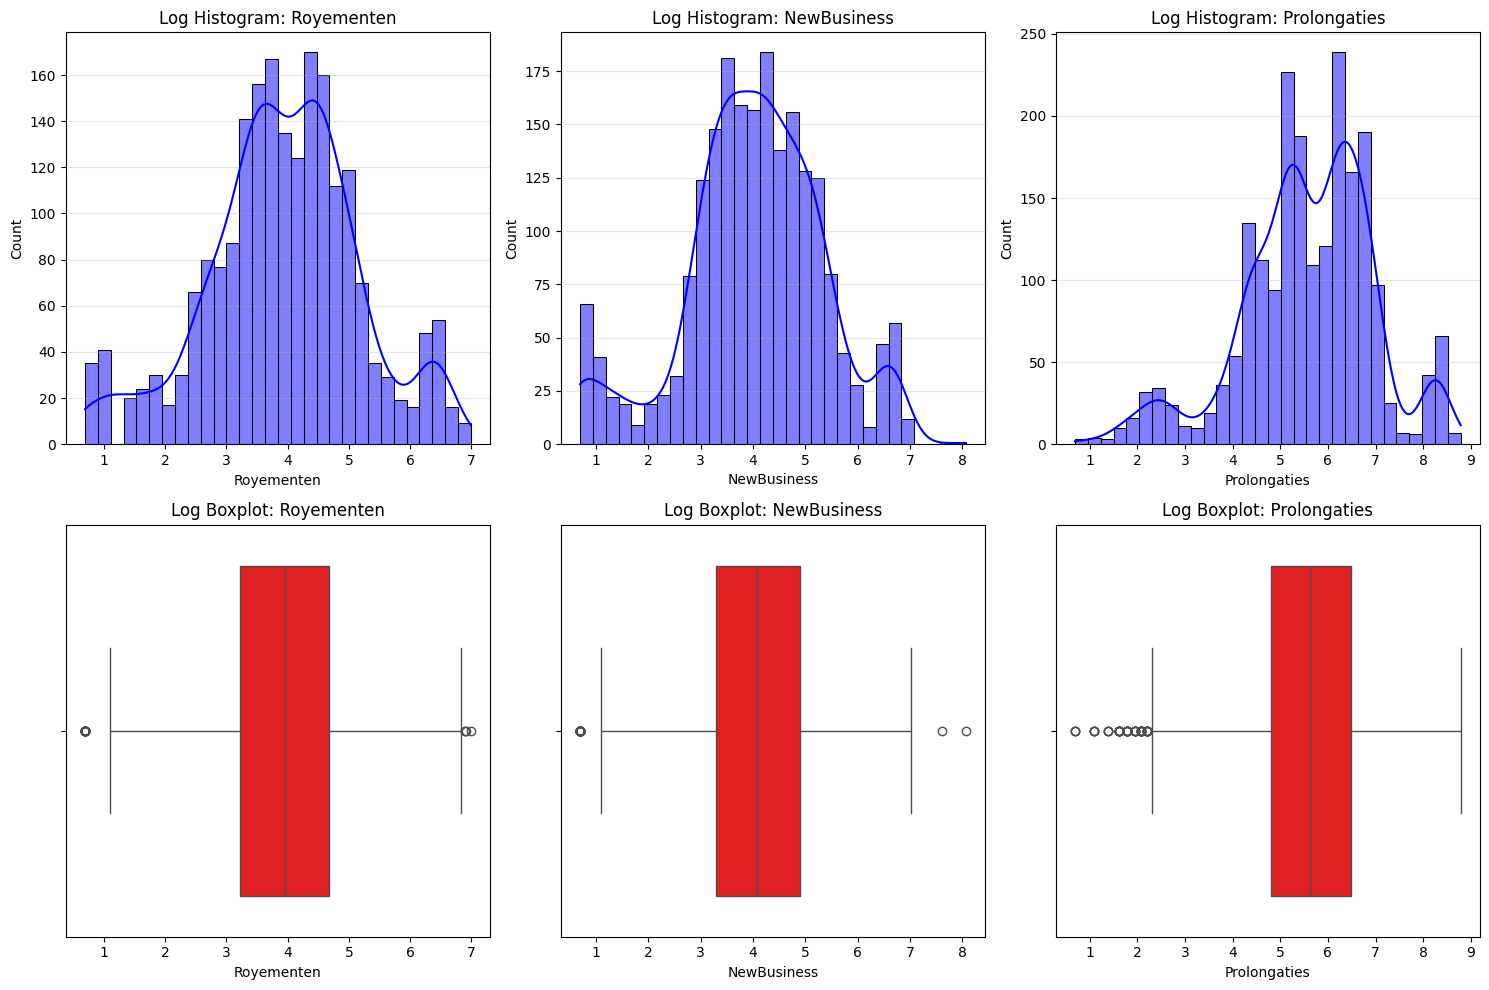

In [65]:
# Log transformation of targets and distribution analysis

# Define targets
targets = ['Royementen', 'NewBusiness', 'Prolongaties']

# Apply log transformation
df_log = df_orig.copy()
for target in targets:
    df_log[target] = np.log1p(df_orig[target])

# Calculate statistics for transformed data
stats_list = []
for target in targets:
    stats_list.append({
        'Target': f'{target} (Log)',
        'Mean': df_log[target].mean(),
        'Median': df_log[target].median(),
        'Std Dev': df_log[target].std(),
        'Min': df_log[target].min(),
        'Max': df_log[target].max(),
        'Skewness': skew(df_log[target]),
        'Kurtosis': kurtosis(df_log[target])
    })

stats_df = pd.DataFrame(stats_list)

# Generate plots for transformed data
plt.figure(figsize=(15, 10))

# Histograms
for i, target in enumerate(targets):
    plt.subplot(2, 3, i+1)
    sns.histplot(df_log[target], kde=True, bins=30, color='blue')
    plt.title(f'Log Histogram: {target}')
    plt.grid(axis='y', alpha=0.3)

# Boxplots
for i, target in enumerate(targets):
    plt.subplot(2, 3, i+4)
    sns.boxplot(x=df_log[target], color='red')
    plt.title(f'Log Boxplot: {target}')

plt.tight_layout()
#plt.savefig('transformed_distributions.png')

print(stats_df.to_string(index=False))

Belangrijkste observaties na transformatie:
1. Skewness (Scheefheid) genormaliseerd: De scheefheid is drastisch verlaagd van waarden boven de $3$ naar waarden tussen de $-0.43$ en $-0.76$. Dit wijst op een bijna normale verdeling. XGBoost presteert hierop veel consistenter omdat de "pijn" van een fout bij een hoge waarde nu vergelijkbaar is met die bij een lage waarde.
2. Kurtosis (Outliers) onder controle: De enorme uitschieters (kurtosis van 40!) zijn verdwenen. De negatieve kurtosis-waarden die je nu ziet, betekenen dat de verdeling iets platter is dan een perfecte normale verdeling, wat voor XGBoost totaal geen probleem is.
3. Mean en Median dichter bij elkaar: Het feit dat het gemiddelde en de mediaan nu heel dicht bij elkaar liggen, is het bewijs dat de invloed van extreme uitschieters is geneutraliseerd.
4. Boxplots: In de boxplots zie je dat de data nu veel compacter is en dat de "staart" met uitschieters aan de rechterkant nagenoeg is verdwenen.

Wat betekent dit voor jouw XGBoost proces?

Door deze transformatie dwing je XGBoost om patronen te leren die gelden voor de hele breedte van je portfolio, in plaats van dat het model alleen maar probeert de 3 grootste uitschieters goed te raden.
Nu we de data-distributies begrijpen en de features hebben voorbereid, zijn we klaar voor de volgende fase: Correlatie-analyse van de features om te zien of we dubbele informatie hebben. 

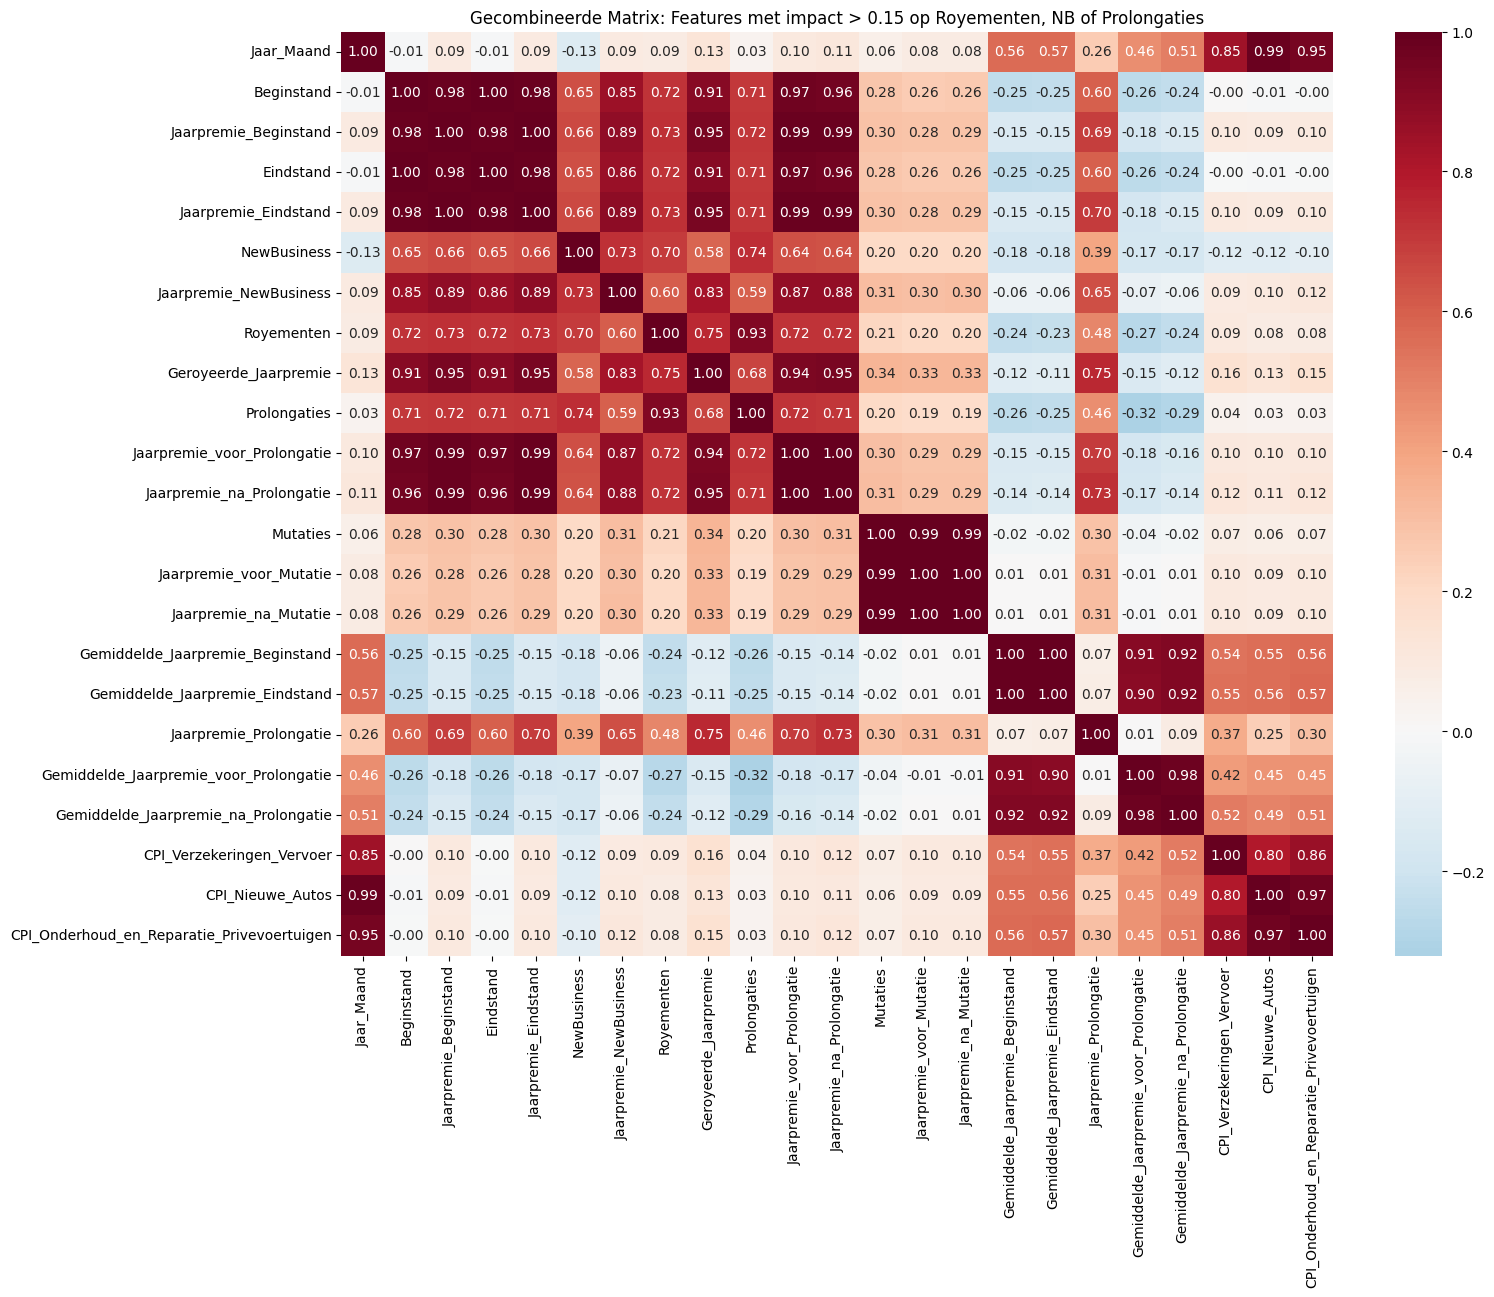

In [68]:
# 1. Bereken de correlatie van ALLE kolommen met ALLE targets
targets = ['Royementen', 'NewBusiness', 'Prolongaties']
all_corrs = numeric_df.corr()[targets]

# 2. Filter: Een kolom mag blijven als de correlatie met MINSTENS ÉÉN target > threshold
threshold = 0.15
# We kijken naar de maximale absolute correlatie over de drie targets heen
mask = all_corrs.abs().max(axis=1) > threshold
selected_features = all_corrs[mask].index.tolist()

# 3. Maak de matrix van deze brede selectie
final_corr_matrix = df_log[selected_features].corr()

# Visualisatie (nu inclusief alle drie de targets in één overzicht)
plt.figure(figsize=(16, 12))
sns.heatmap(final_corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title(f'Gecombineerde Matrix: Features met impact > {threshold} op Royementen, NB of Prolongaties')
plt.show()

De heatmap die je hebt geüpload is een uitstekend vertrekpunt voor de analyse van je model. Het laat de correlaties zien tussen de drie targets (NewBusiness, Prolongaties, Royementen) en een groot aantal features.

Hier is een diepe duik in wat we hier zien en hoe dit je XGBoost-strategie beïnvloedt:

1. De "Inter-Target" Relatie
- Prolongaties & NewBusiness (0.64): Er is een sterke positieve correlatie. Dit is logisch: labels die hard groeien (veel NewBusiness) hebben vaak ook een grotere portefeuille die moet worden geprolongeerd.
- Royementen & Prolongaties (0.50): Ook hier een duidelijke relatie. Hoe groter het volume dat geprolongeerd wordt, hoe groter de absolute kans op opzeggingen (churn).

2. De Kracht van Lags (Autocorrelatie)
De heatmap bevestigt dat dit een tijdreeks-probleem is.
- Kijk naar de blokken bij Royementen_lag1, NewBusiness_lag1, etc. De correlaties zijn hier extreem hoog (vaak > 0.80).
- Conclusie voor XGBoost: Je model zal zwaar leunen op wat er vorige maand gebeurde. Dat is goed voor de stabiliteit, maar de echte waarde van je model zit in de andere features die de afwijkingen van deze trend voorspellen.

3. De Impact van de Expert Features
- Retention_Rate (-0.11 t.o.v. Royementen): Dit lijkt laag, maar let op het negatieve teken. Het bevestigt dat een hogere retentie leidt tot minder royementen. Omdat dit een ratio is, haalt het de ruis van de portefeuille-omvang weg.
- Prolongatie_Pct_Increase (0.01): Zoals eerder besproken, is de lineaire correlatie bijna nul. Dit is een klassiek voorbeeld van een feature die in een lineair model niks doet, maar in XGBoost goud waard is. De impact van prijsverhogingen is namelijk niet lineair: pas boven een bepaalde drempelwaarde (bijv. 10%) schieten de royementen omhoog.

4. CPI & Externe Factoren
- De kolommen onderaan (CPI-data) laten lagere correlaties zien (vaak rond de 0.05 - 0.15).
- Analyse: Dit is volkomen normaal. Economische factoren zijn "zwakke signalen" die subtiele druk uitoefenen op het gedrag. XGBoost is juist heel goed in het oppikken van deze zwakke signalen en ze te combineren met de sterke signalen (lags) om een nauwkeurige forecast te maken.

Wat valt op als we kijken naar de "threshold"?
Als we een threshold van |0.15| aanhouden, zien we dat:
1. Lags & Rolling Means dominant aanwezig zijn (verwacht).
2. Portfolio-omvang (Beginstand) essentieel is voor het volume.
3. Specifieke prijsfeatures net op de grens zitten, maar hun waarde pas bewijzen in combinatie-regels binnen de beslisbomen.

Volgende stap:
De heatmap bewijst dat je een gezonde mix hebt van historische trends (sterke correlatie) en verklarende factoren (subtiele correlatie).